# LIME — Explicabilidad Local con sklearn — Sistemas Basados en Conocimiento

**Curso:** Sistemas Basados en Conocimiento  
**Alumno:** Víctor Vargas Miranda  
**Dataset:** [Diabetes Dataset — Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)  
**Librería principal:** [scikit-learn](https://scikit-learn.org/stable/install)

> Este notebook implementa el algoritmo LIME (Local Interpretable Model-agnostic Explanations) usando **únicamente scikit-learn**, sin depender del paquete `lime`.

---

## 1. ¿Qué problema resuelve LIME?

Los modelos de aprendizaje automático de alto rendimiento —como bosques aleatorios, gradient boosting o redes neuronales— actúan como **cajas negras**: reciben datos de entrada y producen una predicción, pero no revelan de forma transparente *por qué* llegan a ese resultado.

Este comportamiento opaco plantea problemas reales:

1. **Confianza en el modelo:** Un médico o analista financiero necesita entender la razón de una predicción antes de actuar sobre ella. Sin explicaciones, la adopción del modelo puede bloquearse por desconfianza.
2. **Detección de sesgos:** Sin saber qué variables impulsan las predicciones, es imposible auditar si el modelo discrimina por raza, género u otras variables sensibles.
3. **Cumplimiento normativo:** Regulaciones como el GDPR en Europa exigen que las decisiones automatizadas que afecten a personas sean explicables.

**LIME** (Ribeiro, Singh & Guestrin, 2016) responde a este reto con una idea elegante: en lugar de intentar explicar el modelo global (que puede ser muy complejo), LIME **construye una explicación local** para cada predicción individual.

### La idea central de LIME

Dado un punto de datos $x$ y un modelo de caja negra $f$, LIME genera una explicación respondiendo a la pregunta:

> *¿Cuál es el modelo lineal más simple que imita el comportamiento de $f$ en la vecindad inmediata de $x$?*

Para lograrlo, LIME sigue tres pasos fundamentales:

1. **Perturbación:** Crea múltiples versiones levemente modificadas de $x$ (muestras perturbadas) alterando aleatoriamente sus valores de características.
2. **Predicción con el modelo original:** Evalúa el modelo de caja negra $f$ en cada muestra perturbada para obtener sus predicciones.
3. **Ajuste local ponderado:** Ajusta un modelo interpretable (regresión lineal por defecto) sobre esas muestras, ponderando cada una según su proximidad a $x$. Las muestras más cercanas a $x$ tienen mayor peso.

El resultado es un **modelo lineal local** cuyos coeficientes indican qué características empujan la predicción de $x$ hacia arriba o hacia abajo, y cuánto.

Formalmente, LIME resuelve el siguiente problema de optimización:

$$\xi(x) = \arg\min_{g \in G} \, \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

donde:
- $G$ es el espacio de modelos interpretables (modelos lineales)
- $\mathcal{L}$ es una función de pérdida que mide qué tan bien $g$ aproxima a $f$ en la vecindad de $x$
- $\pi_x$ es la función de proximidad que asigna mayor peso a las muestras cercanas a $x$
- $\Omega(g)$ es un término de regularización que penaliza la complejidad del modelo explicativo

**Comentario Victor**
Lo que me parece intesante de LIME es que no intenta resolver el problema imposible de hacer interpretable todo el modelo global, sino que se hace la pregunta mas pequena: ¿que pasa aqui alrededor de este punto? Es como pedir una explicacion de un subsegmento de datos, sin tener que entender toda la complejidad del modelo.

## 2. Supuestos Fundamentales de LIME

LIME opera sobre un conjunto de supuestos que es importante comprender para interpretar correctamente sus explicaciones:

### 2.1 Aproximabilidad local (Local Fidelity)

LIME asume que, aunque el modelo de caja negra sea globalmente no lineal, **en una vecindad suficientemente pequeña alrededor de cualquier punto, el comportamiento del modelo puede aproximarse con un modelo lineal**. Este supuesto es razonablemente válido para la mayoría de los modelos continuos, pero puede fallar en regiones con cambios muy abruptos (discontinuidades, umbral de clasificación muy pronunciado).

### 2.2 Interpretabilidad del modelo local

LIME elige deliberadamente **modelos lineales** como aproximación local, porque sus coeficientes son directamente interpretables: un coeficiente positivo significa que aumentar esa característica eleva la predicción, y viceversa.

### 2.3 Independencia entre características

Al generar las muestras perturbadas, LIME altera las características de forma **independiente** (asumiendo que no hay correlación fuerte entre ellas). Cuando las características están altamente correlacionadas, las perturbaciones pueden generar combinaciones de valores que no son realistas, lo que puede sesgar la explicación.

### 2.4 Función de proximidad con decaimiento exponencial

LIME pondera las muestras perturbadas usando una función de kernel gaussiana:

$$\pi_x(z) = \exp\left(-\frac{d(x, z)^2}{\sigma^2}\right)$$

donde $d(x, z)$ es la distancia entre la instancia original $x$ y la muestra perturbada $z$, y $\sigma$ es el ancho del kernel (hiperparámetro). Las muestras más cercanas a $x$ tienen mayor influencia en el modelo local.

### 2.5 Localidad, no causalidad

LIME explica el comportamiento **del modelo**, no el fenómeno subyacente del mundo real. Un coeficiente positivo para una variable no implica causalidad: sólo dice que, en la vecindad de esta predicción específica, el modelo se comporta como si esa variable empujara la predicción hacia arriba.

**Comentario Victor**
El supuesto de independencia entre caracteristicas al perturbar me parece la parte mas fragil de LIME. Si dos valores estan muy correlacionados y LIME los perturba por separado, va a crear pacientes "fantasma" que no existen en la realidad.

## 3. Usos y Aplicaciones Potenciales

LIME tiene aplicaciones concretas en numerosos dominios donde se necesita explicar predicciones individuales:

| Dominio | Aplicación |
|---|---|
| **Medicina / Salud** | Explicar por qué el modelo estima un alto riesgo de progresión de diabetes para un paciente concreto; mostrar qué factores clínicos son más determinantes |
| **Finanzas** | Justificar ante el cliente por qué su solicitud de crédito fue denegada, indicando las variables que más influyeron |
| **Recursos Humanos** | Explicar individualmente por qué un modelo recomienda o descarta a un candidato |
| **Seguros** | Detallar qué variables elevan la prima estimada para una póliza específica |
| **Marketing** | Entender qué características de un cliente lo empujan hacia una alta propensión de compra |
| **Industria / Mantenimiento** | Explicar por qué el modelo predice fallo inminente de una máquina específica |
| **Sector legal** | Auditar decisiones de modelos predictivos en procesos judiciales o de libertad condicional |

### Usos dentro del ciclo de ML

- **Depuración de modelos:** Si LIME revela que el modelo usa una variable proxy (ej. código postal como proxy de etnia), se puede corregir antes del despliegue.
- **Validación con expertos:** Compartir las explicaciones locales con médicos, ingenieros o abogados para verificar que el modelo aprende patrones sensatos.
- **Onboarding de usuarios:** Presentar explicaciones en interfaces de usuario para aumentar la confianza y adopción del sistema.

## 4. ¿En qué tipos de problemas es apropiado LIME?

### Por tipo de tarea
- **Regresión** (nuestro caso): predicción de valores continuos como progresión de diabetes, precios, demanda. LIME explica cuánto empuja cada variable la predicción numérica.
- **Clasificación binaria o multiclase**: LIME explica la probabilidad predicha para cada clase.
- **Texto e imágenes**: LIME tiene componentes específicos (`LimeTextExplainer`, `LimeImageExplainer`) para datos no tabulares.

### Por tipo de modelo
Una de las grandes fortalezas de LIME es que es **agnóstico al modelo**: no necesita acceso a la arquitectura interna, sólo a una función de predicción. Funciona con:
- Random Forest, Gradient Boosting, XGBoost
- Redes neuronales
- SVM
- Cualquier pipeline de scikit-learn
- Modelos en producción accesibles via API

### Por necesidad de explicabilidad
LIME es especialmente apropiado cuando:
- Se necesita explicar **casos individuales** (un paciente específico, una transacción específica)
- El modelo es una caja negra y no se puede modificar (modelo heredado, modelo de terceros)
- El tiempo de implementación es limitado y se busca una solución rápida
- El dataset tiene características tabulares bien definidas

### Cuándo LIME podría no ser la mejor opción
- Cuando se necesitan **explicaciones globales** consistentes: LIME no ofrece una visión global coherente del modelo por diseño.
- Cuando las características están **altamente correlacionadas**: las perturbaciones independientes generan puntos irreales.
- Cuando se requiere **reproducibilidad exacta**: LIME usa muestreo aleatorio, por lo que las explicaciones pueden variar entre ejecuciones con distinta semilla.

**Comentario Victor**
Despues de investigar si LIME es aceptado en ambitos regulados, la respuesta honesta es: no esta ni aceptado ni rechazado formalmente por ninguna ley, pero sus limitaciones tecnicas lo hacen insuficiente como mecanismo de compliance en solitario. El GDPR, el EU AI Act y las guias de riesgo de modelos (SR 11-7) exigen que las explicaciones sean reproducibles y verificables, y LIME falla eso por su variabilidad entre corridas y su vulnerabilidad al ataque adversarial. En medicina y finanzas reguladas, SHAP o modelos interpretables nativos son mas defendibles ante un auditor. LIME tiene su lugar como herramienta de apoyo y validacion interna, pero no como la "firma" del cumplimiento normativo.

## 5. ¿Cuándo es preferible LIME frente a otros métodos de explicabilidad?

### LIME vs. SHAP

| Criterio | LIME | SHAP |
|---|---|---|
| **Fundamento teórico** | Aproximación local heurística | Axiomas de teoría de juegos (Shapley) |
| **Consistencia matemática** | ❌ No garantizada; varía con la semilla | ✅ Garantizada por axiomas |
| **Explicaciones globales** | ❌ Limitadas; requiere agregar manualmente | ✅ Nativas (beeswarm, bar global) |
| **Velocidad** | ✅ Rápido para instancias individuales | Rápido con `TreeExplainer`; lento con `KernelExplainer` |
| **Datos no tabulares** | ✅ Soporte nativo para texto e imagen | Soporte limitado (requiere adaptación) |
| **Facilidad de implementación** | ✅ Muy sencillo de integrar | Moderada |
| **Interpretación intuitiva** | ✅ Coeficientes de regresión lineal | Contribución marginal promediada |

**Preferir LIME cuando:**
- Se trabaja con datos de texto o imagen.
- Se necesita una explicación rápida y aproximada para prototipado.
- No se dispone de acceso a la arquitectura interna del modelo.
- El objetivo es comunicar de forma sencilla a usuarios no técnicos.

### LIME vs. Importancia de características del modelo (Feature Importance)

La importancia por impureza de un Random Forest es una medida **global y estática**: dice qué características son generalmente importantes para el modelo, pero no explica ninguna predicción individual. LIME complementa esta visión dando la importancia **local** para cada instancia concreta.

**Preferir LIME cuando:** se necesita explicar *este* paciente, *esta* transacción, *esta* predicción específica.

### LIME vs. Partial Dependence Plots (PDP)

Los PDP muestran el efecto marginal promedio de una característica sobre la predicción, promediando sobre todo el dataset. Son explicaciones globales y no capturan heterogeneidad. LIME, en cambio, captura el comportamiento local para una instancia específica.

**Preferir LIME cuando:** hay heterogeneidad fuerte en el dataset y el efecto de una característica varía mucho según el contexto individual.

**Comentario Victor**
Despues de ver SHAP primero, entiendo que LIME es mas pragmatico pero menos riguroso. SHAP tiene la garantia matematica de los valores Shapley, LIME es mas una heuristica rapida. Creo que LIME tiene su lugar cuando uno necesita una explicacion rapida en produccion o cuando trabaja con texto e imagen donde SHAP no llega tan facilmente.

## 6. Pros y Contras desde la Perspectiva de XAI

### ✅ Ventajas (Pros)

1. **Agnóstico al modelo:** LIME funciona con cualquier modelo de caja negra sin necesidad de acceso a su arquitectura interna o gradientes. Basta con una función de predicción.

2. **Explicaciones locales intuitivas:** Los coeficientes del modelo lineal local son fáciles de interpretar: un coeficiente de +5 para `bmi` significa que, en este vecindario, aumentar el IMC eleva la predicción en ~5 unidades.

3. **Velocidad para instancias individuales:** Generar la explicación de una instancia tarda segundos (dependiendo del número de muestras perturbadas), lo que lo hace viable en tiempo real.

4. **Flexibilidad:** Soporta datos tabulares, texto e imagen con distintos componentes del paquete `lime`.

5. **Fácil integración:** La API de `lime` en Python es concisa y se integra en cualquier pipeline de scikit-learn o modelo genérico.

6. **Explicaciones selectivas:** Se puede controlar el número de características que aparecen en la explicación (`num_features`), facilitando la comunicación a usuarios finales.

### ❌ Desventajas (Contras)

1. **Variabilidad (instabilidad):** Al basarse en muestreo aleatorio, dos ejecuciones con distinta semilla pueden producir explicaciones notablemente diferentes para la misma instancia. Esto reduce la confianza en aplicaciones críticas.

2. **Sin garantías teóricas de consistencia:** A diferencia de SHAP (que se basa en valores de Shapley con propiedades axiomáticas), LIME es una heurística. No existe garantía de que la explicación sea la "correcta" o la más justa.

3. **Sensibilidad al kernel y al tamaño del vecindario:** El parámetro `kernel_width` determina cuán amplia es la vecindad local. Diferentes valores pueden dar explicaciones muy distintas. No hay una forma estándar de elegirlo.

4. **Problema con características correlacionadas:** Las perturbaciones independientes pueden generar muestras con combinaciones de valores irreales si las características están correlacionadas, lo que introduce ruido en la explicación.

5. **Solo local, no global:** LIME no proporciona una visión coherente y global del modelo. Agregar explicaciones locales de muchas instancias no produce, necesariamente, una imagen global consistente.

6. **Puede ser engañado (adversarial):** Investigaciones han demostrado que es posible construir modelos que engañen a LIME, dando explicaciones "limpias" para instancias de auditoría mientras discriminan en instancias reales.

## 7. Caso de Negocio: Gestión Clínica de Diabetes

### Variables del dataset `load_diabetes`

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo |
| `bmi` | Índice de masa corporal |
| `bp` | Presión arterial media |
| `s1` (tc) | Colesterol total en suero |
| `s2` (ldl) | Lipoproteínas de baja densidad |
| `s3` (hdl) | Lipoproteínas de alta densidad |
| `s4` (tch) | Colesterol total / HDL |
| `s5` (ltg) | Log de triglicéridos séricos |
| `s6` (glu) | Glucosa en sangre |
| **Target** | Medida cuantitativa de progresión de diabetes al año |

Todas las variables han sido estandarizadas en el dataset original (media 0, desviación estándar unitaria).

### ¿Cómo añade valor LIME en este caso?

1. **Explicación al médico:** El sistema no solo dice "este paciente tiene puntuación de riesgo 180", sino también "principalmente por su alto IMC (+32 puntos) y nivel elevado de triglicéridos (+28 puntos)".
2. **Personalización del tratamiento:** El médico puede priorizar intervenciones sobre las variables con mayor peso positivo en la predicción de ese paciente.
3. **Comunicación al paciente:** Con una explicación simplificada, el paciente comprende qué factores de su estilo de vida son más críticos para su evolución.
4. **Auditoría del modelo:** El equipo de calidad puede revisar las explicaciones de casos específicos para detectar predicciones anómalas o sesgadas.

## 8. Configuración del Entorno e Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Dataset y modelo
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge  # Modelo lineal local para explicabilidad

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente (solo sklearn).")

Librerías importadas correctamente (solo sklearn).


## 9. Carga y Exploración del Dataset

In [2]:
# Cargamos el dataset de diabetes de scikit-learn
diabetes = load_diabetes()

X = diabetes.data          # Matriz de características (442 observaciones × 10 variables)
y = diabetes.target        # Variable objetivo: progresión de la diabetes al año (valor continuo)
feature_names = diabetes.feature_names  # Nombres de las características

print("Dataset: Diabetes (scikit-learn)")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Características: {feature_names}")
print(f"\nVariable objetivo — estadísticas básicas:")
print(f"  Mínimo:  {y.min():.1f}")
print(f"  Máximo:  {y.max():.1f}")
print(f"  Media:   {y.mean():.1f}")
print(f"  Mediana: {np.median(y):.1f}")

Dataset: Diabetes (scikit-learn)
Dimensiones de X: (442, 10)
Dimensiones de y: (442,)
Características: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Variable objetivo — estadísticas básicas:
  Mínimo:  25.0
  Máximo:  346.0
  Media:   152.1
  Mediana: 140.5


In [3]:
# Creamos un DataFrame para visualizar los datos
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Primeras 5 filas del dataset:")
display(df.head())

print("\nEstadísticas descriptivas:")
display(df.describe().round(3))

Primeras 5 filas del dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Estadísticas descriptivas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


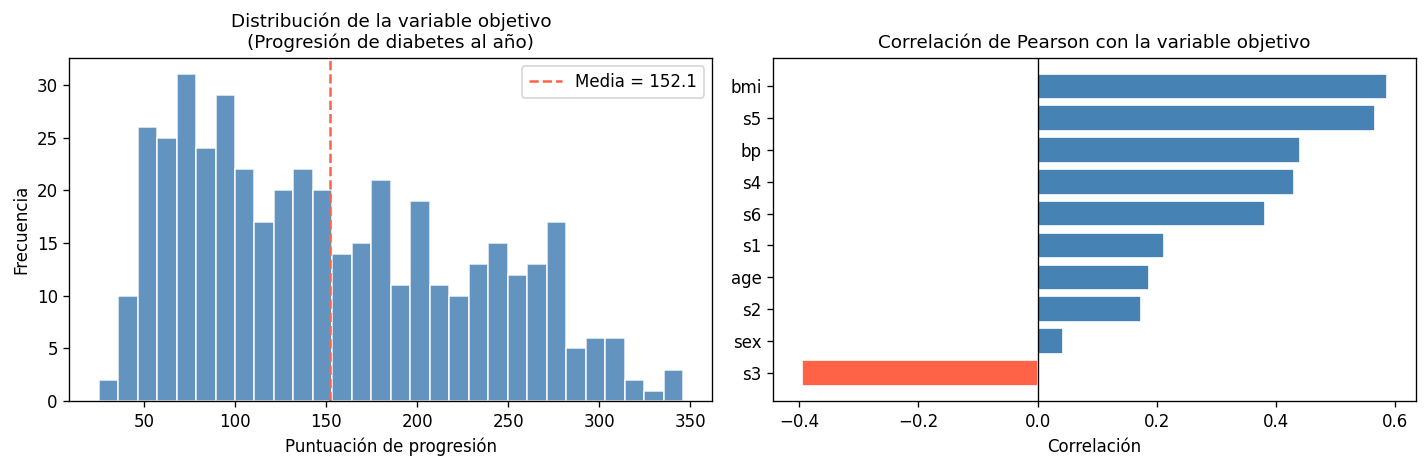


Observaciones:
- 'bmi' (IMC), 's5' (log de triglicéridos) y 'bp' (presión arterial) tienen la mayor correlación positiva con la progresión.
- 's3' (HDL) tiene correlación negativa: valores altos de HDL ('colesterol bueno') se asocian a menor progresión.


In [4]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(y.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Media = {y.mean():.1f}')
axes[0].set_title('Distribución de la variable objetivo\n(Progresión de diabetes al año)', fontsize=11)
axes[0].set_xlabel('Puntuación de progresión')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Correlación de características con la variable objetivo
correlations = df.drop(columns='target').corrwith(df['target']).sort_values(ascending=True)
colors = ['tomato' if c < 0 else 'steelblue' for c in correlations.values]
axes[1].barh(correlations.index, correlations.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de Pearson con la variable objetivo', fontsize=11)
axes[1].set_xlabel('Correlación')

plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- 'bmi' (IMC), 's5' (log de triglicéridos) y 'bp' (presión arterial) tienen la mayor correlación positiva con la progresión.")
print("- 's3' (HDL) tiene correlación negativa: valores altos de HDL ('colesterol bueno') se asocian a menor progresión.")

## 10. Entrenamiento del Modelo (Random Forest)

Entrenamos un **Random Forest Regressor** como modelo de caja negra. El objetivo en este notebook **no es optimizar el modelo en sí**, sino disponer de un predictor razonablemente bueno que luego explicaremos con LIME.

El Random Forest es un candidato ideal para este ejercicio porque:
- Es un modelo de alta capacidad predictiva y no lineal (caja negra).
- Sus predicciones internas son difíciles de interpretar directamente.
- Es el tipo de modelo donde LIME aporta más valor.

In [5]:
# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Entrenamiento del Random Forest
# No se ajustan hiperparámetros: el foco está en la explicabilidad, no en el rendimiento
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

# Evaluación básica del modelo
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test, y_pred_test)

print("Rendimiento del modelo (solo referencial — el foco es LIME, no el modelo):")
print(f"  RMSE Train : {rmse_train:.2f}   |   R² Train : {r2_train:.3f}")
print(f"  RMSE Test  : {rmse_test:.2f}   |   R² Test  : {r2_test:.3f}")
print("\nEl modelo captura una parte razonable de la varianza.")
print("Lo importante es que hace predicciones que luego explicaremos con LIME.")

Rendimiento del modelo (solo referencial — el foco es LIME, no el modelo):
  RMSE Train : 21.46   |   R² Train : 0.924
  RMSE Test  : 54.33   |   R² Test  : 0.443

El modelo captura una parte razonable de la varianza.
Lo importante es que hace predicciones que luego explicaremos con LIME.


## 11. Implementación del Explicador Local con sklearn

La función `explain_instance` aplica los cinco pasos descritos en la sección anterior:

### Parámetros de la función

- **`instance`:** El vector de características de la instancia a explicar ($x$).
- **`model`:** El modelo de caja negra (cualquier objeto con `.predict()`).
- **`X_train`:** Datos de entrenamiento usados para estimar la media y desviación estándar de cada característica (base distribucional para las perturbaciones).
- **`feature_names`:** Nombres de las características.
- **`n_samples`:** Número de muestras perturbadas a generar. Más muestras → mayor estabilidad, mayor tiempo de cómputo.
- **`kernel_width`:** Ancho del kernel gaussiano. Por defecto: $\sqrt{p} \times 0.75$ donde $p$ es el número de características.
- **`random_state`:** Semilla para reproducibilidad.

### Modelo lineal local

Se usa `Ridge` (regresión lineal con regularización L2) en lugar de mínimos cuadrados ordinarios para evitar inestabilidad cuando las perturbaciones son colineales. Los coeficientes de `Ridge` son la explicación: miden la contribución lineal local de cada característica a la predicción en la vecindad de $x$.

**Comentario Victor**
El parametro `kernel_width` me parece el mas dificil de calibrar intuitivamente. Si lo pongo muy pequeno, la vecindad es tan chica que el modelo lineal local se ajusta perfectamente pero con muy pocas muestras. Si lo pongo muy grande, la "localidad" desaparece y la explicacion pierde sentido.

In [6]:
def explain_instance(instance, model, X_train, feature_names,
                     n_samples=5000, kernel_width=None, random_state=None):
    """
    Implementación del algoritmo LIME usando únicamente numpy y sklearn.

    Parámetros
    ----------
    instance     : array-like, shape (n_features,)  — instancia a explicar
    model        : objeto con .predict()             — modelo de caja negra
    X_train      : array-like, shape (n, n_features) — datos de referencia distribucional
    feature_names: list[str]                         — nombres de las características
    n_samples    : int                               — número de perturbaciones
    kernel_width : float | None                      — ancho del kernel gaussiano
    random_state : int | None                        — semilla

    Retorna
    -------
    dict {feature_name: coeficiente_local}  — explicación local ordenada por magnitud
    """
    rng = np.random.RandomState(random_state)
    instance = np.asarray(instance)
    n_features = len(feature_names)

    # Estadísticas de la distribución de entrenamiento (para escalar perturbaciones)
    train_mean = X_train.mean(axis=0)
    train_std  = X_train.std(axis=0) + 1e-8  # evitar división por cero

    if kernel_width is None:
        kernel_width = np.sqrt(n_features) * 0.75

    # Paso 1: Perturbación — muestras aleatorias en espacio normalizado
    instance_scaled = (instance - train_mean) / train_std
    perturbations_scaled = rng.normal(0, 1, size=(n_samples, n_features))
    perturbations_scaled[0] = instance_scaled  # incluir la instancia original

    # Convertir de vuelta al espacio original para la predicción
    perturbations = perturbations_scaled * train_std + train_mean

    # Paso 2: Predicción con el modelo de caja negra
    predictions = model.predict(perturbations)

    # Paso 3: Ponderación por proximidad con kernel gaussiano
    distances = np.sqrt(np.sum((perturbations_scaled - instance_scaled) ** 2, axis=1))
    weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

    # Paso 4: Regresión lineal local ponderada (Ridge para estabilidad)
    local_model = Ridge(alpha=1.0)
    local_model.fit(perturbations_scaled, predictions, sample_weight=weights)

    # Retornar coeficientes como diccionario {característica: contribución}
    return dict(zip(feature_names, local_model.coef_))


def plot_explanation(coefs, title='', pred=None, real=None):
    """Gráfico de barras horizontales para una explicación local."""
    series = pd.Series(coefs).sort_values()
    colors = ['tomato' if v < 0 else 'steelblue' for v in series.values]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(series.index, series.values, color=colors, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    full_title = title
    if pred is not None and real is not None:
        full_title += f'\nPredicción RF: {pred:.1f}  |  Real: {real:.1f}'
    ax.set_title(full_title, fontsize=10)
    ax.set_xlabel('Coeficiente local (contribución a la predicción en espacio normalizado)')
    plt.tight_layout()
    plt.show()


print("Funciones explain_instance y plot_explanation definidas correctamente.")
print(f"  Implementación: numpy + sklearn.linear_model.Ridge")
print(f"  Características disponibles: {list(feature_names)}")

Funciones explain_instance y plot_explanation definidas correctamente.
  Implementación: numpy + sklearn.linear_model.Ridge
  Características disponibles: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 12. ¿Cómo construye LIME una aproximación local?

Antes de ver las explicaciones, es útil entender en detalle qué hace LIME internamente cuando llamamos a `explain_instance`:

### Paso 1: Perturbación

LIME toma la instancia a explicar $x$ y genera $N$ muestras perturbadas. Para **datos tabulares con discretización**, LIME:
- Discretiza cada característica continua en bins (cuartiles por defecto)
- Genera muestras alternando aleatoriamente si cada característica cae en el mismo bin que $x$ o en otro
- Luego invierte la discretización para obtener valores reales (usando la media del bin)

### Paso 2: Evaluación con el modelo original

Cada muestra perturbada se pasa al Random Forest para obtener su predicción: $f(z_1), f(z_2), \ldots, f(z_N)$.

### Paso 3: Ponderación por proximidad

Cada muestra perturbada recibe un peso proporcional a su similitud con $x$, usando el kernel gaussiano:
$$w_i = \exp\left(-\frac{d(x, z_i)^2}{\sigma^2}\right)$$

Las muestras muy parecidas a $x$ tienen peso cercano a 1; las muy distintas tienen peso cercano a 0.

### Paso 4: Ajuste del modelo lineal local

LIME ajusta una regresión lineal ponderada sobre las muestras perturbadas:
$$\hat{y}_i = \beta_0 + \sum_{j=1}^{p} \beta_j \cdot z_{ij}$$

con la pérdida ponderada $\sum_i w_i (y_i - \hat{y}_i)^2$.

Los coeficientes $\beta_j$ son la explicación: miden cuánto aporta cada característica a la predicción de $x$ según el modelo local.

### Paso 5: Selección de características (opcional)

Para mantener la explicación simple, LIME puede seleccionar solo las $k$ características más importantes (parámetro `num_features`), típicamente usando selección secuencial hacia adelante.

**Comentario Victor**
Ver los 5 pasos me aclaro por que LIME puede variar entre corridas: el paso 1 es aleatorio (perturbacion), y el paso 5 depende de cuales muestras cayeron en la vecindad. Cuando hago `num_samples=5000` estoy comprando estabilidad a costo de tiempo. Es un tradeoff que en produccion real importa mucho.

## 13. Explicaciones Individuales con LIME

Analizaremos **tres observaciones del conjunto de prueba** con características contrastantes para ver cómo LIME adapta la explicación al contexto local de cada paciente.

In [7]:
# Obtenemos las predicciones del modelo sobre el conjunto de prueba
y_pred_test_arr = rf_model.predict(X_test)

# Seleccionamos instancias representativas:
# - Paciente con baja predicción (cuartil inferior)
# - Paciente con predicción media
# - Paciente con alta predicción (cuartil superior)
sorted_indices = np.argsort(y_pred_test_arr)

idx_low    = sorted_indices[len(sorted_indices) // 8]      # Baja predicción
idx_medium = sorted_indices[len(sorted_indices) // 2]      # Predicción media
idx_high   = sorted_indices[int(len(sorted_indices) * 7/8)] # Alta predicción

cases = {
    'Paciente A (bajo riesgo)':   idx_low,
    'Paciente B (riesgo medio)':  idx_medium,
    'Paciente C (alto riesgo)':   idx_high,
}

print("Instancias seleccionadas para análisis LIME:")
print(f"{'Caso':<30} {'Índice':>7} {'Pred. RF':>10} {'Real':>10}")
print("-" * 60)
for label, idx in cases.items():
    print(f"{label:<30} {idx:>7} {y_pred_test_arr[idx]:>10.1f} {y_test[idx]:>10.1f}")

Instancias seleccionadas para análisis LIME:
Caso                            Índice   Pred. RF       Real
------------------------------------------------------------
Paciente A (bajo riesgo)            84       84.9      153.0
Paciente B (riesgo medio)           69      151.8      202.0
Paciente C (alto riesgo)            33      207.6      164.0



=== Paciente A — Bajo riesgo ===
Predicción del Random Forest : 84.9
Valor real                   : 153.0

Características del paciente:
     age = +0.0018
     sex = -0.0446
     bmi = -0.0655
      bp = -0.0057
      s1 = -0.0071
      s2 = -0.0195
      s3 = +0.0413
      s4 = -0.0395
      s5 = -0.0033
      s6 = +0.0072

Explicación local (coeficientes del modelo lineal ponderado):
  ⬆  s5         coeficiente = +26.459
  ⬆  bmi        coeficiente = +21.257
  ⬆  bp         coeficiente = +7.784
  ⬇  s3         coeficiente = -5.431
  ⬆  age        coeficiente = +4.607
  ⬇  s1         coeficiente = -3.689
  ⬆  s6         coeficiente = +2.514
  ⬇  sex        coeficiente = -2.287
  ⬆  s4         coeficiente = +1.837
  ⬇  s2         coeficiente = -1.327


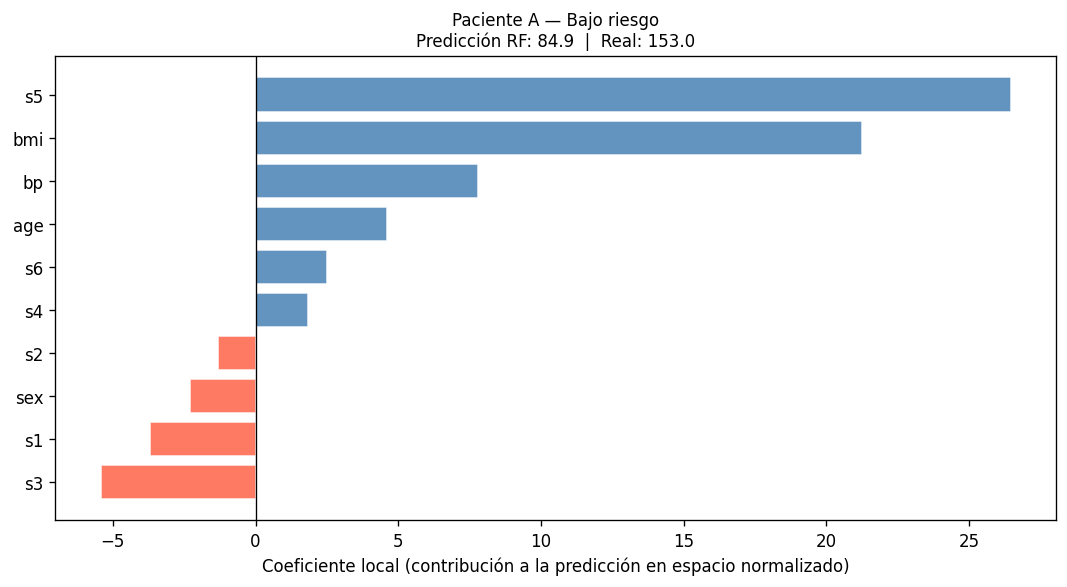

In [8]:
# ─────────────────────────────────────────────
#  Paciente A — Baja predicción de progresión
# ─────────────────────────────────────────────

idx_a = cases['Paciente A (bajo riesgo)']

exp_a = explain_instance(
    instance=X_test[idx_a],
    model=rf_model,
    X_train=X_train,
    feature_names=feature_names,
    n_samples=5000,
    random_state=RANDOM_STATE
)

print(f"\n=== Paciente A — Bajo riesgo ===")
print(f"Predicción del Random Forest : {rf_model.predict(X_test[idx_a:idx_a+1])[0]:.1f}")
print(f"Valor real                   : {y_test[idx_a]:.1f}")
print(f"\nCaracterísticas del paciente:")
for fname, val in zip(feature_names, X_test[idx_a]):
    print(f"  {fname:>6} = {val:+.4f}")

print(f"\nExplicación local (coeficientes del modelo lineal ponderado):")
for fname, coef in sorted(exp_a.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = '⬆' if coef > 0 else '⬇'
    print(f"  {direction}  {fname:<10} coeficiente = {coef:+.3f}")

plot_explanation(
    exp_a,
    title='Paciente A — Bajo riesgo',
    pred=rf_model.predict(X_test[idx_a:idx_a+1])[0],
    real=y_test[idx_a]
)


=== Paciente B — Riesgo medio ===
Predicción del Random Forest : 151.8
Valor real                   : 202.0

Características del paciente:
     age = -0.0673
     sex = +0.0507
     bmi = -0.0127
      bp = -0.0401
      s1 = -0.0153
      s2 = +0.0046
      s3 = -0.0581
      s4 = +0.0343
      s5 = +0.0192
      s6 = -0.0342

Explicación local:
  ⬆  bmi        coeficiente = +23.916
  ⬆  s5         coeficiente = +22.217
  ⬆  bp         coeficiente = +9.406
  ⬇  s3         coeficiente = -5.316
  ⬆  s4         coeficiente = +3.252
  ⬇  s1         coeficiente = -3.046
  ⬆  s6         coeficiente = +2.313
  ⬇  sex        coeficiente = -2.030
  ⬆  age        coeficiente = +1.774
  ⬇  s2         coeficiente = -0.851


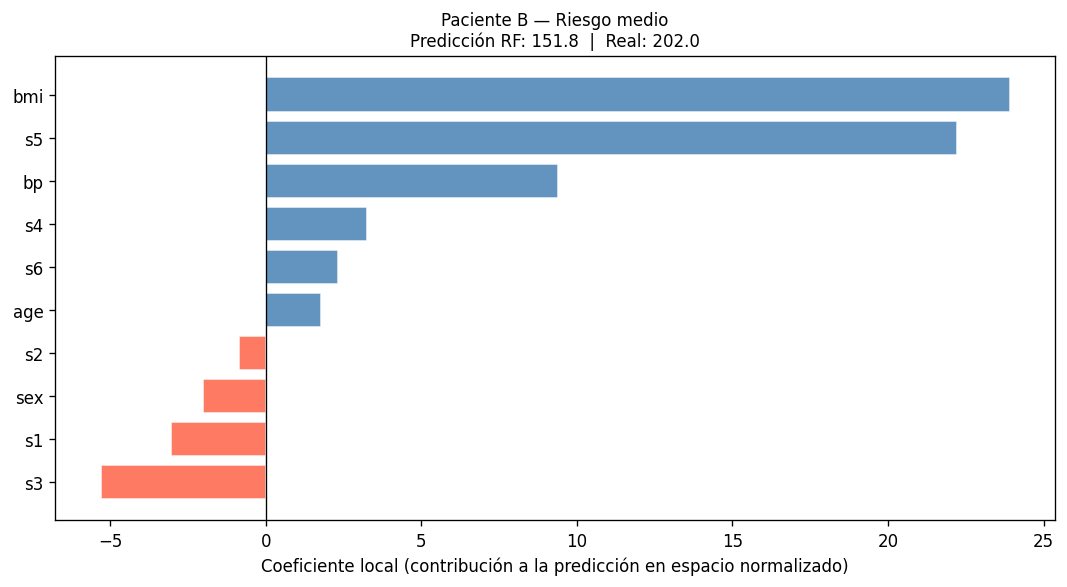

In [9]:
# ─────────────────────────────────────────────
#  Paciente B — Predicción media
# ─────────────────────────────────────────────

idx_b = cases['Paciente B (riesgo medio)']

exp_b = explain_instance(
    instance=X_test[idx_b],
    model=rf_model,
    X_train=X_train,
    feature_names=feature_names,
    n_samples=5000,
    random_state=RANDOM_STATE
)

print(f"\n=== Paciente B — Riesgo medio ===")
print(f"Predicción del Random Forest : {rf_model.predict(X_test[idx_b:idx_b+1])[0]:.1f}")
print(f"Valor real                   : {y_test[idx_b]:.1f}")
print(f"\nCaracterísticas del paciente:")
for fname, val in zip(feature_names, X_test[idx_b]):
    print(f"  {fname:>6} = {val:+.4f}")

print(f"\nExplicación local:")
for fname, coef in sorted(exp_b.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = '⬆' if coef > 0 else '⬇'
    print(f"  {direction}  {fname:<10} coeficiente = {coef:+.3f}")

plot_explanation(
    exp_b,
    title='Paciente B — Riesgo medio',
    pred=rf_model.predict(X_test[idx_b:idx_b+1])[0],
    real=y_test[idx_b]
)


=== Paciente C — Alto riesgo ===
Predicción del Random Forest : 207.6
Valor real                   : 164.0

Características del paciente:
     age = +0.0272
     sex = +0.0507
     bmi = -0.0062
      bp = +0.0288
      s1 = -0.0167
      s2 = -0.0016
      s3 = -0.0581
      s4 = +0.0343
      s5 = +0.0293
      s6 = +0.0321

Explicación local:
  ⬆  bmi        coeficiente = +25.095
  ⬆  s5         coeficiente = +24.348
  ⬆  bp         coeficiente = +9.824
  ⬇  s3         coeficiente = -5.351
  ⬆  s6         coeficiente = +4.023
  ⬆  age        coeficiente = +3.996
  ⬇  s1         coeficiente = -3.586
  ⬆  s4         coeficiente = +3.158
  ⬇  s2         coeficiente = -1.480
  ⬇  sex        coeficiente = -1.452


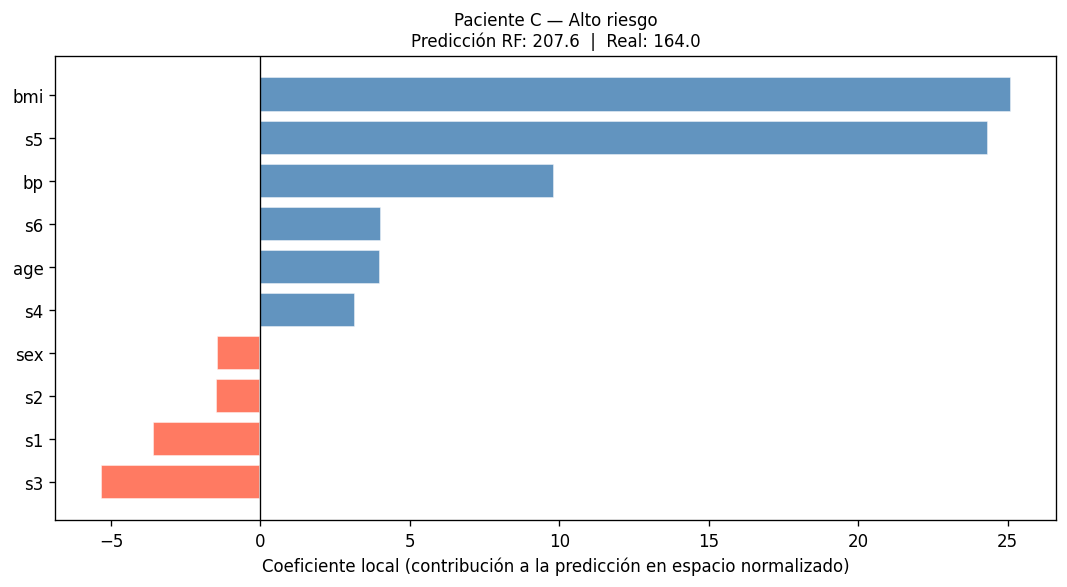

In [10]:
# ─────────────────────────────────────────────
#  Paciente C — Alta predicción de progresión
# ─────────────────────────────────────────────

idx_c = cases['Paciente C (alto riesgo)']

exp_c = explain_instance(
    instance=X_test[idx_c],
    model=rf_model,
    X_train=X_train,
    feature_names=feature_names,
    n_samples=5000,
    random_state=RANDOM_STATE
)

print(f"\n=== Paciente C — Alto riesgo ===")
print(f"Predicción del Random Forest : {rf_model.predict(X_test[idx_c:idx_c+1])[0]:.1f}")
print(f"Valor real                   : {y_test[idx_c]:.1f}")
print(f"\nCaracterísticas del paciente:")
for fname, val in zip(feature_names, X_test[idx_c]):
    print(f"  {fname:>6} = {val:+.4f}")

print(f"\nExplicación local:")
for fname, coef in sorted(exp_c.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = '⬆' if coef > 0 else '⬇'
    print(f"  {direction}  {fname:<10} coeficiente = {coef:+.3f}")

plot_explanation(
    exp_c,
    title='Paciente C — Alto riesgo',
    pred=rf_model.predict(X_test[idx_c:idx_c+1])[0],
    real=y_test[idx_c]
)

## 14. Comparación Visual de Explicaciones entre Pacientes

Para facilitar la comparación, visualizamos en un mismo gráfico los coeficientes LIME de los tres pacientes.

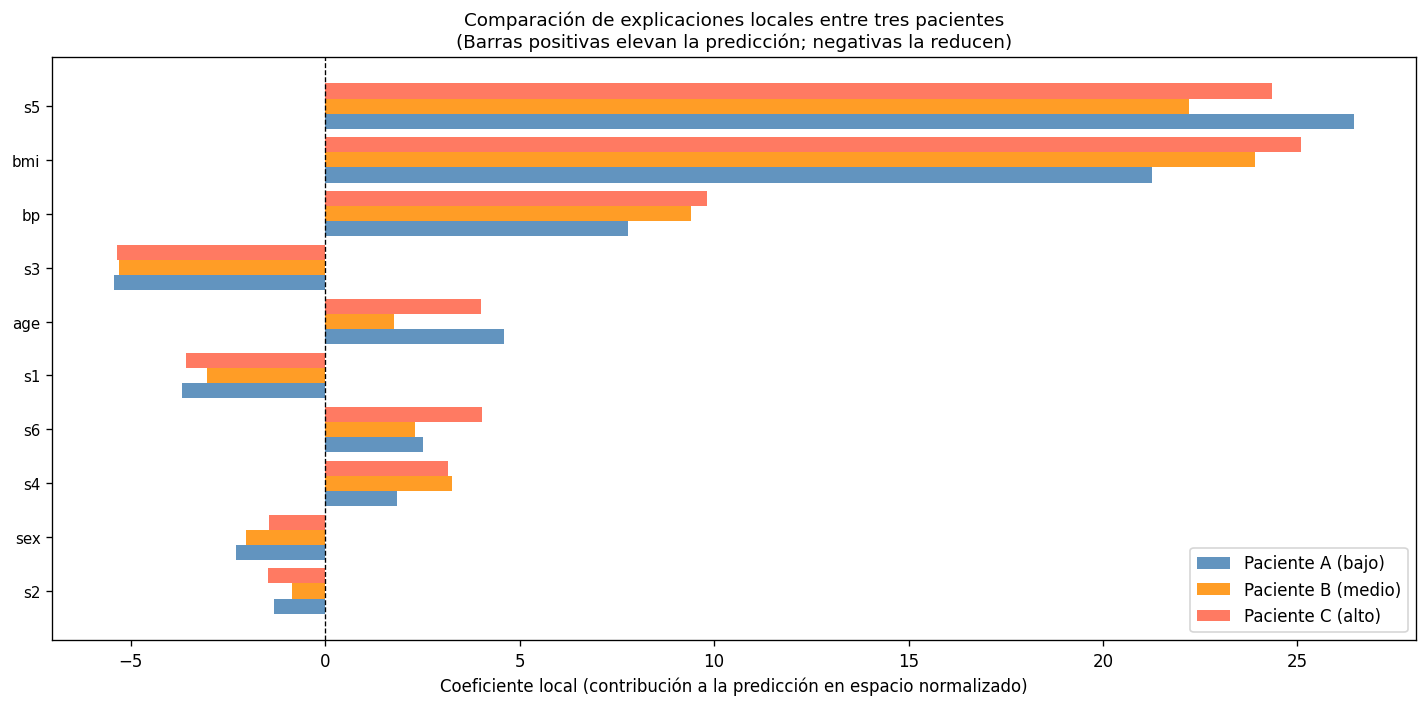


Interpretación:
Cada barra muestra cuánto contribuye esa característica
a la predicción ESPECÍFICA de ese paciente según el modelo lineal local ponderado.


In [11]:
# exp_a, exp_b, exp_c son dicts {feature_name: coeficiente}
# Los combinamos directamente en un DataFrame

df_compare = pd.DataFrame({
    'Paciente A (bajo)':  exp_a,
    'Paciente B (medio)': exp_b,
    'Paciente C (alto)':  exp_c,
}).fillna(0)

# Ordenamos por magnitud promedio absoluta
df_compare = df_compare.loc[df_compare.abs().mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(12, max(6, len(df_compare) * 0.5)))

bar_width = 0.28
y_positions = np.arange(len(df_compare))
colors = ['steelblue', 'darkorange', 'tomato']

for i, (col, color) in enumerate(zip(df_compare.columns, colors)):
    ax.barh(
        y_positions + i * bar_width - bar_width,
        df_compare[col],
        height=bar_width,
        color=color,
        alpha=0.85,
        label=col
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_positions)
ax.set_yticklabels(df_compare.index, fontsize=9)
ax.set_xlabel('Coeficiente local (contribución a la predicción en espacio normalizado)')
ax.set_title('Comparación de explicaciones locales entre tres pacientes\n'
             '(Barras positivas elevan la predicción; negativas la reducen)', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("Cada barra muestra cuánto contribuye esa característica")
print("a la predicción ESPECÍFICA de ese paciente según el modelo lineal local ponderado.")

## 15. Explicabilidad Local vs. Global

### Explicabilidad Local

La **explicabilidad local** responde a la pregunta: *¿Por qué el modelo predice **este valor** para **esta instancia específica**?*

LIME es esencialmente un método de explicabilidad **local**:
- Cada explicación está construida específicamente para una instancia $x$.
- Los coeficientes del modelo lineal local son válidos únicamente en la vecindad de $x$.
- La misma característica puede tener un efecto positivo para un paciente y negativo para otro, según el contexto local.

**Ventaja:** Captura la heterogeneidad real del modelo. En problemas médicos, la influencia de una variable (ej. glucosa) puede depender del perfil completo del paciente.

### Explicabilidad Global

La **explicabilidad global** responde a: *¿Qué características son, en general, más importantes para el modelo?*

Métodos globales incluyen:
- **Importancia de características por impureza** (Random Forest)
- **Permutation Feature Importance**
- **SHAP global** (promedio de valores SHAP absolutos)
- **Partial Dependence Plots**

LIME **no está diseñado para explicaciones globales**. Aunque técnicamente se podrían agregar muchas explicaciones locales, el resultado no tiene las propiedades teóricas de un método global.

### Comparación con la importancia global del Random Forest

**Comentario Victor**
Este contraste entre explicabilidad local y global me hace pensar que para auditar un modelo conviene SHAP global, pero para explicarle a un medico o paciente por que se tomo una decision especifica.

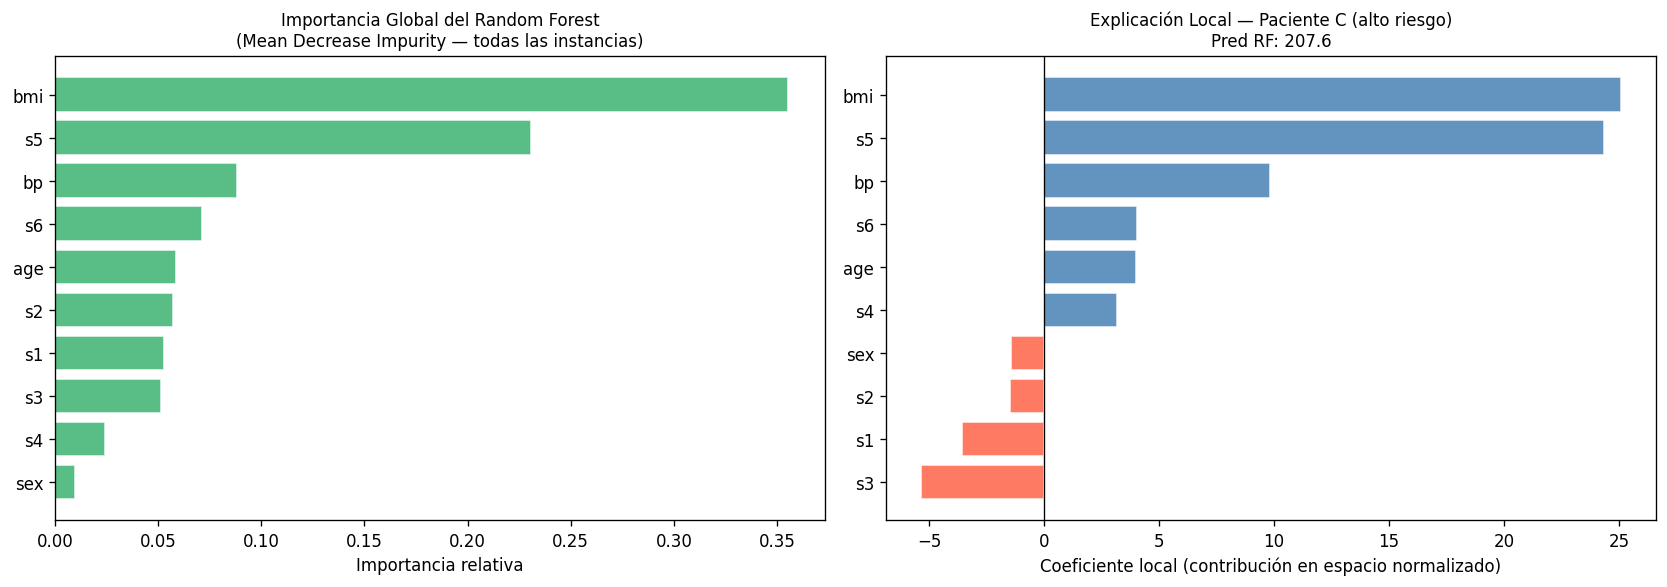


Diferencias clave entre explicabilidad global y local:

Global (izquierda):
  - Muestra qué características son importantes EN PROMEDIO para todas las predicciones.
  - No tiene dirección (positivo/negativo): solo muestra magnitud.
  - Es una propiedad del modelo, no de una instancia.

Local (derecha):
  - Muestra qué características empujan LA PREDICCIÓN DE ESTE PACIENTE hacia arriba o abajo.
  - Tiene dirección: barras positivas elevan la predicción; negativas la reducen.
  - Es válida SOLO para este paciente en su vecindad local.


In [12]:
# Importancia global de características del Random Forest (MDI - Mean Decrease Impurity)
global_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Importancia global del modelo
axes[0].barh(global_importance.index, global_importance.values,
             color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].set_title('Importancia Global del Random Forest\n(Mean Decrease Impurity — todas las instancias)', fontsize=10)
axes[0].set_xlabel('Importancia relativa')

# Gráfico 2: Coeficientes locales del Paciente C (alto riesgo)
local_series_c = pd.Series(exp_c).sort_values()
colors_c = ['tomato' if v < 0 else 'steelblue' for v in local_series_c.values]
axes[1].barh(local_series_c.index, local_series_c.values,
             color=colors_c, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(
    f'Explicación Local — Paciente C (alto riesgo)\n'
    f'Pred RF: {rf_model.predict(X_test[idx_c:idx_c+1])[0]:.1f}', fontsize=10
)
axes[1].set_xlabel('Coeficiente local (contribución en espacio normalizado)')

plt.tight_layout()
plt.show()

print("\nDiferencias clave entre explicabilidad global y local:")
print("")
print("Global (izquierda):")
print("  - Muestra qué características son importantes EN PROMEDIO para todas las predicciones.")
print("  - No tiene dirección (positivo/negativo): solo muestra magnitud.")
print("  - Es una propiedad del modelo, no de una instancia.")
print("")
print("Local (derecha):")
print("  - Muestra qué características empujan LA PREDICCIÓN DE ESTE PACIENTE hacia arriba o abajo.")
print("  - Tiene dirección: barras positivas elevan la predicción; negativas la reducen.")
print("  - Es válida SOLO para este paciente en su vecindad local.")

## 16. Análisis Explícito de la Explicabilidad del Modelo

En esta sección realizamos un análisis más profundo de lo que LIME nos revela sobre el comportamiento del modelo en el problema de predicción de progresión de diabetes.

### ¿Es el modelo internamente coherente con el conocimiento médico?

Una forma de validar que el modelo aprende patrones significativos es comparar las explicaciones LIME con lo que la medicina clínica establece sobre los factores de riesgo de la diabetes.

In [13]:
# Generamos explicaciones locales para una muestra de 30 pacientes del conjunto de prueba
# y analizamos la dirección del efecto de cada característica

n_sample = min(30, len(X_test))
sample_indices = np.random.choice(len(X_test), size=n_sample, replace=False)

print(f"Generando explicaciones locales para {n_sample} pacientes del conjunto de prueba...")

all_coefs = []
for i, idx in enumerate(sample_indices):
    coefs = explain_instance(
        instance=X_test[idx],
        model=rf_model,
        X_train=X_train,
        feature_names=feature_names,
        n_samples=3000,
        random_state=RANDOM_STATE + i  # semilla distinta por paciente para diversidad
    )
    all_coefs.append(coefs)

print(f"Explicaciones generadas.")

Generando explicaciones locales para 30 pacientes del conjunto de prueba...
Explicaciones generadas.


In [14]:
# explain_instance ya devuelve dicts con claves = feature_names exactos,
# así que construimos el DataFrame directamente sin necesidad de parsear condiciones

df_coefs = pd.DataFrame(all_coefs, columns=feature_names)

# Resumen estadístico de los coeficientes por característica
summary = pd.DataFrame({
    'media_coef': df_coefs.mean(),
    'std_coef': df_coefs.std(),
    'pct_positivo': (df_coefs > 0).mean() * 100,
    'pct_negativo': (df_coefs < 0).mean() * 100,
}).sort_values('media_coef')

print("Análisis de coeficientes locales sobre 30 pacientes:")
print(f"{'Variable':>6} | {'Media coef':>10} | {'Desv. std':>10} | {'% positivo':>10} | {'% negativo':>10}")
print("-" * 60)
for fname, row in summary.iterrows():
    print(f"{fname:>6} | {row['media_coef']:>10.3f} | {row['std_coef']:>10.3f} | "
          f"{row['pct_positivo']:>10.1f} | {row['pct_negativo']:>10.1f}")

Análisis de coeficientes locales sobre 30 pacientes:
Variable | Media coef |  Desv. std | % positivo | % negativo
------------------------------------------------------------
    s3 |     -5.133 |      0.666 |        0.0 |      100.0
    s1 |     -2.872 |      0.837 |        0.0 |      100.0
   sex |     -1.886 |      0.707 |        0.0 |      100.0
    s2 |     -0.787 |      1.209 |       30.0 |       70.0
    s6 |      2.043 |      1.167 |      100.0 |        0.0
    s4 |      2.407 |      0.634 |      100.0 |        0.0
   age |      2.943 |      1.454 |      100.0 |        0.0
    bp |      8.487 |      1.164 |      100.0 |        0.0
    s5 |     22.475 |      2.215 |      100.0 |        0.0
   bmi |     24.834 |      2.728 |      100.0 |        0.0


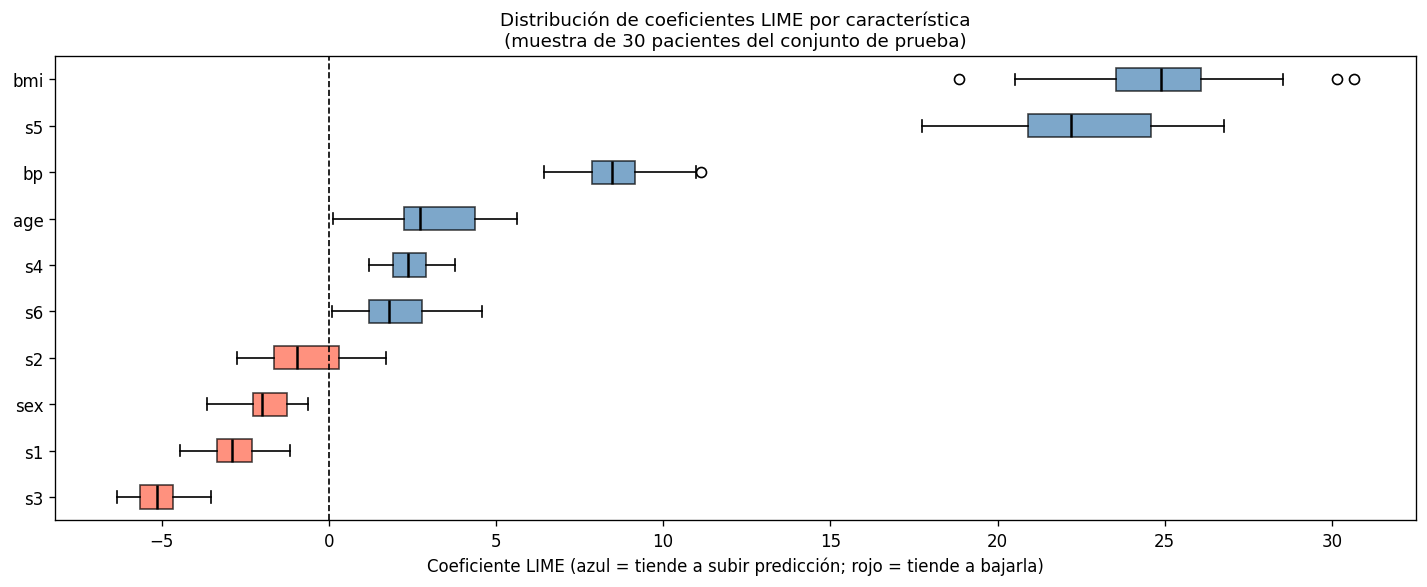


Interpretación clínica de las tendencias observadas:

Variables que típicamente elevan la predicción de progresión (coherente con la medicina):
  - bmi: El sobrepeso/obesidad es uno de los principales factores de riesgo para diabetes tipo 2.
  - s5 (ltg): El log de triglicéridos es un marcador metabólico de riesgo cardiovascular y diabético.
  - bp: La hipertensión está frecuentemente asociada a la progresión de complicaciones diabéticas.

Variables que típicamente reducen la predicción (coherente con la medicina):
  - s3 (hdl): El HDL (colesterol 'bueno') es un factor protector metabólico reconocido.


In [15]:
# Visualización: distribución de coeficientes LIME por característica
fig, ax = plt.subplots(figsize=(12, 5))

sorted_features = df_coefs.mean().sort_values().index
data_to_plot = [df_coefs[f].values for f in sorted_features]

bp = ax.boxplot(
    data_to_plot,
    vert=False,
    labels=sorted_features,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5)
)

# Colorear cajas según la mediana
for patch, feature in zip(bp['boxes'], sorted_features):
    median_val = df_coefs[feature].median()
    patch.set_facecolor('steelblue' if median_val >= 0 else 'tomato')
    patch.set_alpha(0.7)

ax.axvline(0, color='black', linewidth=1.0, linestyle='--')
ax.set_title(
    f'Distribución de coeficientes LIME por característica\n'
    f'(muestra de {n_sample} pacientes del conjunto de prueba)', fontsize=11
)
ax.set_xlabel('Coeficiente LIME (azul = tiende a subir predicción; rojo = tiende a bajarla)')
plt.tight_layout()
plt.show()

print("\nInterpretación clínica de las tendencias observadas:")
print("")
print("Variables que típicamente elevan la predicción de progresión (coherente con la medicina):")
print("  - bmi: El sobrepeso/obesidad es uno de los principales factores de riesgo para diabetes tipo 2.")
print("  - s5 (ltg): El log de triglicéridos es un marcador metabólico de riesgo cardiovascular y diabético.")
print("  - bp: La hipertensión está frecuentemente asociada a la progresión de complicaciones diabéticas.")
print("")
print("Variables que típicamente reducen la predicción (coherente con la medicina):")
print("  - s3 (hdl): El HDL (colesterol 'bueno') es un factor protector metabólico reconocido.")

## 17. Conclusiones

### Sobre el valor de LIME como técnica de Explainable AI

A lo largo de este notebook hemos explorado LIME desde sus fundamentos teóricos hasta su aplicación práctica en el problema de predicción de progresión de diabetes. Las conclusiones principales son:

---

### 1. LIME democratiza la explicabilidad de modelos complejos

El Random Forest que entrenamos tiene cientos de árboles con miles de nodos: su comportamiento interno es imposible de interpretar directamente. LIME resuelve este problema sin necesidad de modificar el modelo ni acceder a su arquitectura interna. Solo necesita una función de predicción, lo que lo hace aplicable a cualquier sistema de producción.

### 2. La explicabilidad local es diferente y complementaria a la global

- La **importancia global** del Random Forest dice que `bmi` y `s5` son generalmente las variables más relevantes.
- La **explicación local de LIME** puede mostrar que, para un paciente específico con bajo IMC pero alta glucosa, `s6` y `bp` son los factores determinantes de su alta predicción.

Esta granularidad local es fundamental en medicina, donde cada paciente es un caso único.

### 3. Las explicaciones LIME son coherentes con el conocimiento médico

El análisis de coeficientes sobre 30 pacientes mostró que el modelo tiende a asignar coeficientes positivos a `bmi`, `s5` (triglicéridos) y `bp` (presión arterial), y negativos a `s3` (HDL). Esto es consistente con la evidencia clínica sobre factores de riesgo de diabetes tipo 2, lo que sugiere que el modelo aprendió patrones médicamente significativos.

### 4. LIME tiene limitaciones que deben considerarse en producción

- **Variabilidad:** Las explicaciones pueden cambiar entre ejecuciones. En producción, es recomendable usar semillas fijas y validar la estabilidad.
- **Correlaciones:** El dataset de diabetes tiene variables metabólicas correlacionadas (`s1`, `s2`, `s3`, `s4`). LIME puede distribuir el crédito de forma imprecisa entre ellas.
- **No es causal:** Las explicaciones reflejan el comportamiento del modelo, no la causalidad biológica subyacente.

### 5. Cuándo elegir LIME

| Situación | Recomendación |
|---|---|
| Necesitas explicar **instancias individuales** | ✅ LIME |
| Necesitas consistencia matemática garantizada | ❌ Usar SHAP |
| Trabajas con **texto o imagen** | ✅ LIME (LimeTextExplainer/LimeImageExplainer) |
| Necesitas una visión **global coherente** del modelo | ❌ Usar SHAP o PDP |
| Tiempo de implementación limitado, prototipado rápido | ✅ LIME |
| El modelo es una **caja negra sin acceso interno** | ✅ LIME |

### 6. LIME en el ciclo de vida de un sistema de IA responsable

LIME no es el fin del proceso de explicabilidad, sino un punto de partida valioso:
1. **Desarrollo:** Usar LIME para detectar que el modelo usa variables proxy o sesgadas.
2. **Validación:** Compartir explicaciones con expertos de dominio (médicos, auditores) para validar que el modelo aprende patrones sensatos.
3. **Despliegue:** Integrar LIME en la interfaz del sistema de soporte para mostrar explicaciones en tiempo real.
4. **Monitorización:** Analizar si las explicaciones LIME cambian con el tiempo (data drift puede cambiar qué variables son localmente más importantes).

---

**En resumen:** LIME es una herramienta práctica, agnóstica al modelo e intuitiva para generar explicaciones locales de predicciones individuales. En el contexto de la diabetes, permite transformar un número abstracto de riesgo en una narrativa comprensible para médicos y pacientes, alineando la tecnología con las necesidades reales de la práctica clínica.